## Read the Data

In [1]:
# !pip install numpy
# !pip install matplotlib
# !pip install seaborn
# !pip install pandas
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Suppress common warnings for cleaner notebook output
import warnings

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
pd.options.mode.chained_assignment = None

In [2]:

saved_df = "data/dpu_results_choices.csv"
choice_results = pd.read_csv(saved_df)

user_results_path = 'data/dpu_results_users.csv'
user_results = pd.read_csv(user_results_path)


In [3]:
user_results.columns

Index(['user_id', 'group', 'trust_the_agent', 'number_of_choices',
       'number_of_accepts', 'number_of_correct_choices_mean',
       'number_of_correct_choices_feedback', 'final_agent_mean_score',
       'final_agent_name', 'final_agent_rank', 'final_agent_final_part_score',
       'age', 'gender', 'education', 'familiar_with_AI',
       'evaluate_final_agent', 'ES_clear', 'ES_overwhelming',
       'ES_feedback_related', 'ES_helpful', 'ES_combined'],
      dtype='object')

In [4]:
choice_results.columns

Index(['user_id', 'episode', 'group', 'trust_the_agent', 'prev_agent',
       'updated_agent', 'prev_agent_mean_score', 'update_agent_mean_score',
       'prev_agent_feedback_score', 'updated_agent_feedback_score',
       'choice_to_update', 'correct_choice_generalized',
       'correct_choice_feedback', 'choice_time', 'improved_from_prev_feedback',
       'improved_from_prev_mean'],
      dtype='object')

In [5]:
user_results['group'].value_counts()

group
Random              76
Salient-Contrast    73
Control             69
Same                62
Name: count, dtype: int64

# Start Ploting

### Ploting Methods

In [ ]:
colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6'] 
group_names = ['Control', 'Random', 'Same', 'Salient-Contrast']


# Configure matplotlib for Jupyter notebook - use inline backend
%matplotlib inline
def plot_barplot(
    df, 
    x_col, 
    y_col, 
    hue=None, 
    hue_names=None,
    x_val_names=None, 
    figsize=(8, 6), 
    estimator=lambda x: np.mean(x) * 100, 
    errorbar=('ci', 95),
    palette=None,
    x_label='Group', 
    y_label='Correct Choice %',
    order=None,
    bar_label_fmt='%.1f%%',
    ylim_bottom=0,
    save_path=None,
):
    """
    Plots a grouped barplot with annotated counts for each bar.

    Parameters:
        df (pd.DataFrame): DataFrame to plot.
        x_col (str): Column for x-axis.
        y_col (str): Column for y-axis (should be numeric/binary for mean).
        hue (str, optional): Column for grouping bars. Default: None.
        x_val_names (list, optional): Custom x-tick labels.
        figsize (tuple): Figure size.
        estimator (callable): Function to aggregate y_col (default: mean*100).
        errorbar (str): Error bar type for seaborn.
        palette (list, optional): Colors for bars.
        x_label (str, optional): X-axis label.
        y_label (str, optional): Y-axis label.
    """
    if order is None:
        order = sorted(list(df[x_col].unique()))

    plt.figure(figsize=figsize)
    ax = sns.barplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=hue,
        estimator=estimator,
        errorbar=errorbar,
        palette=palette,
        order=order
    )

    for container in ax.containers:
        ax.bar_label(container, fmt=bar_label_fmt, label_type='edge', fontsize=13)#, fontweight='bold')

    if not x_val_names:
        x_val_names = sorted([str(level) for level in order])
    if len(x_val_names[0]) > 15:
        ax.set_xticklabels(x_val_names, rotation=40, ha='right', fontsize=13)
    else:
        ax.set_xticklabels(x_val_names, fontsize=13)
    if x_label:
        plt.xlabel(x_label, fontsize=14)
    if y_label:
        plt.ylabel(y_label, fontsize=14)
    plt.yticks(fontsize=13)

    handles, labels = ax.get_legend_handles_labels()
    if hue:
        if not hue_names:
            hue_names = sorted(list(df[hue].unique()))
        
        if isinstance(hue_names, dict):
            display_labels = [hue_names.get(lbl, lbl) for lbl in labels]
        else:
            display_labels = hue_names
        
        ax.legend(handles=handles, labels=display_labels, fontsize=13)
    plt.ylim(bottom=ylim_bottom)
    plt.show()




In [7]:
from scipy.stats import mannwhitneyu
import itertools

def mannwhitneyu_test(df, y_col, x_col, test_type='two-sided'):
    # Prepare data
    levels = sorted(df[x_col].unique())
    results = []

    for lvl1, lvl2 in itertools.combinations(levels, 2):
        group1 = df[df[x_col] == lvl1][y_col]
        group2 = df[df[x_col] == lvl2][y_col]
        stat, p = mannwhitneyu(group1, group2, alternative=test_type)
        results.append({'level_1': lvl1, 'level_2': lvl2, 'U': stat, 'p_value': p})

    # Convert results to DataFrame for easy viewing
    mannwhitney_results_df = pd.DataFrame(results)
    print(mannwhitney_results_df)



## Ploting

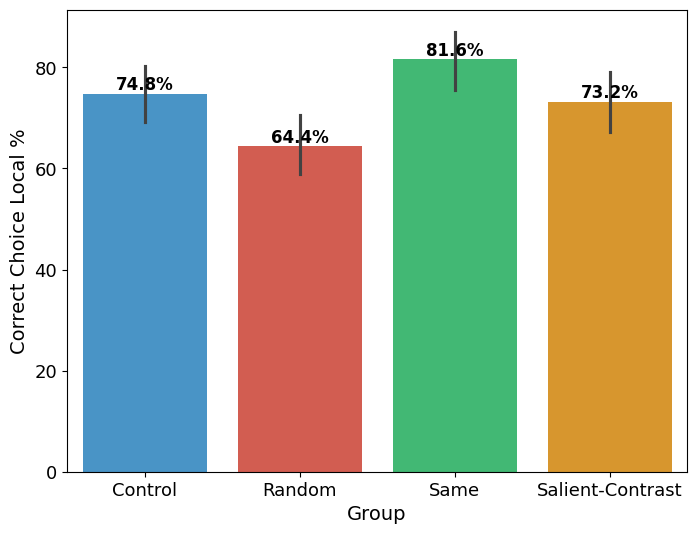

            level_1           level_2        U   p_value
0           Control            Random  33718.5  0.012215
1           Control  Salient-Contrast  26153.0  0.697525
2           Control              Same  21916.5  0.088393
3            Random  Salient-Contrast  26179.5  0.038564
4            Random              Same  21712.5  0.000046
5  Salient-Contrast              Same  20250.5  0.040229


In [ ]:
# Plot: Correct Choice (Local) by Group
# 
plot_barplot(choice_results, 
                     'group', 
                     'correct_choice_feedback', 
                     y_label='Correct Choice Local %',
                     palette=colors_palette,
                     save_path='images/correct_choice_local_by_group.pdf',
                     order=group_names,
                     x_val_names=group_names
                     )

mannwhitneyu_test(choice_results, 'correct_choice_feedback', 'group')

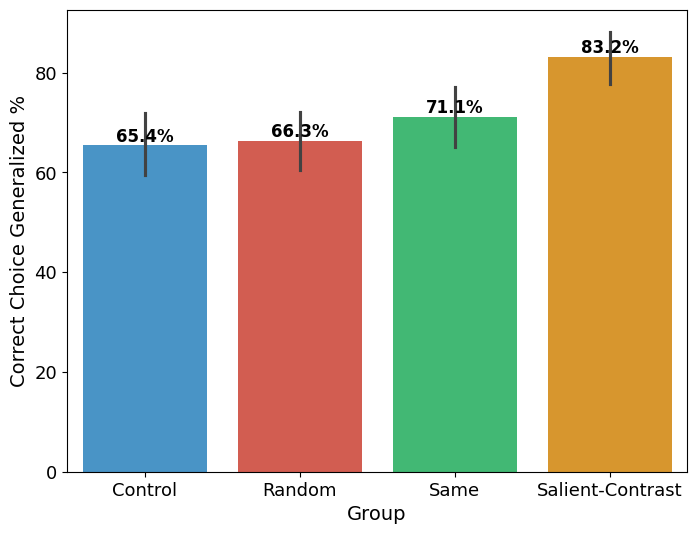

Mann-Whitney U Test Results for Correct Choice (Generalized) by Group
            level_1           level_2        U   p_value
0           Control            Random  30262.5  0.833689
1           Control  Salient-Contrast  21159.0  0.000016
2           Control              Same  22162.5  0.199691
3            Random  Salient-Contrast  23858.5  0.000026
4            Random              Same  24955.5  0.265943
5  Salient-Contrast              Same  24771.5  0.003206


In [9]:
# Plot: Correct Choice (Generalized) by Group
plot_barplot(choice_results, 
                     'group', 
                     'correct_choice_generalized', 
                     palette=colors_palette,
                     y_label='Correct Choice Generalized %',
                     order=group_names,
                     x_val_names=group_names,
                     )

print("Mann-Whitney U Test Results for Correct Choice (Generalized) by Group")
mannwhitneyu_test(choice_results, 'correct_choice_generalized', 'group')

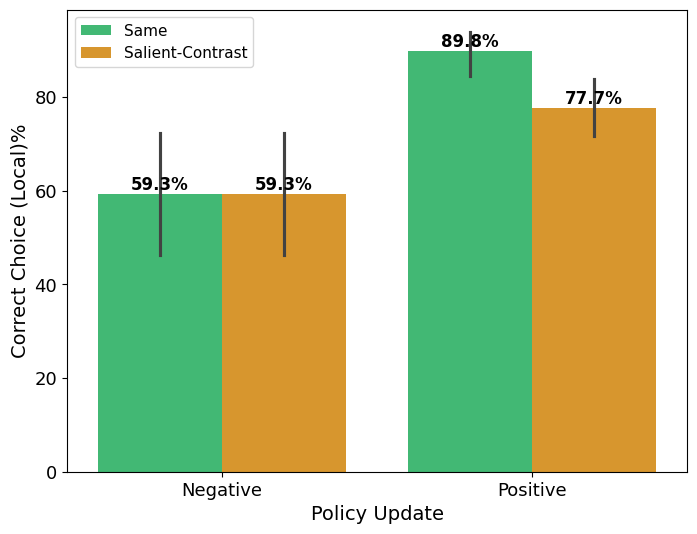

Mann-Whitney U Test Results for Improved from Previous Agent (Local) by Group
            level_1 level_2        U   p_value
0  Salient-Contrast    Same  10726.5  0.004218


In [10]:
# Plot: Correct Choice (Local) by Update Direction Contrast vs Same
plot_df = choice_results[choice_results['group'].isin(group_names[2:4])].copy()
plot_barplot(plot_df,
                     x_col='improved_from_prev_feedback',
                     y_col='correct_choice_feedback',
                     y_label='Correct Choice (Local)%',
                     x_label='Policy Update',
                     x_val_names=['Negative', 'Positive'],
                     hue='group',
                     hue_names=list(plot_df['group'].unique()),
                    palette=colors_palette[2:],

)

print("Mann-Whitney U Test Results for Improved from Previous Agent (Local) by Group")
mannwhitneyu_test(plot_df[plot_df['improved_from_prev_feedback'] == 1], 'correct_choice_feedback', 'group')

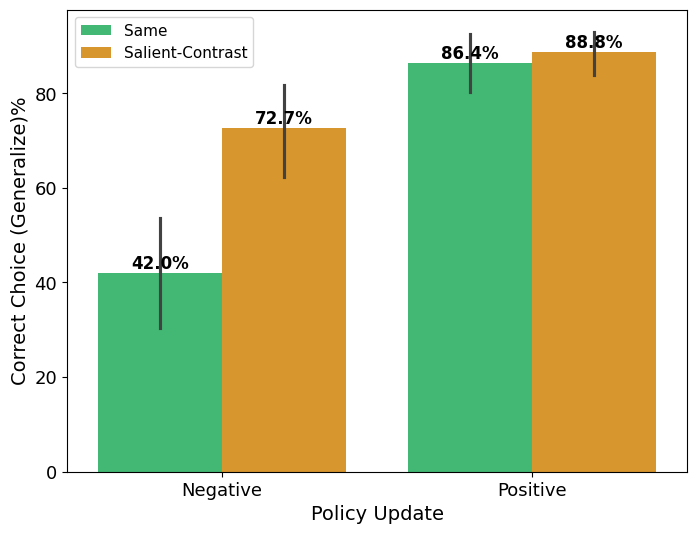

Mann-Whitney U Test Results for Improved from Previous Agent (Generalize) by Group
            level_1 level_2       U   p_value
0  Salient-Contrast    Same  3472.0  0.000184


In [11]:
# Plot: Correct Choice (Generalize) by Update Direction Contrast vs Same
plot_df = choice_results[choice_results['group'].isin(group_names[2:4])].copy()
plot_barplot(plot_df,
                     x_col='improved_from_prev_mean',
                     y_col='correct_choice_generalized',
                     y_label='Correct Choice (Generalize)%',
                     x_label='Policy Update',
                     x_val_names=['Negative', 'Positive'],
                     hue='group',
                     hue_names=list(plot_df['group'].unique()),
                    palette=colors_palette[2:],

)

print("Mann-Whitney U Test Results for Improved from Previous Agent (Generalize) by Group")
mannwhitneyu_test(plot_df[plot_df['improved_from_prev_mean'] == 0], 'correct_choice_generalized', 'group')

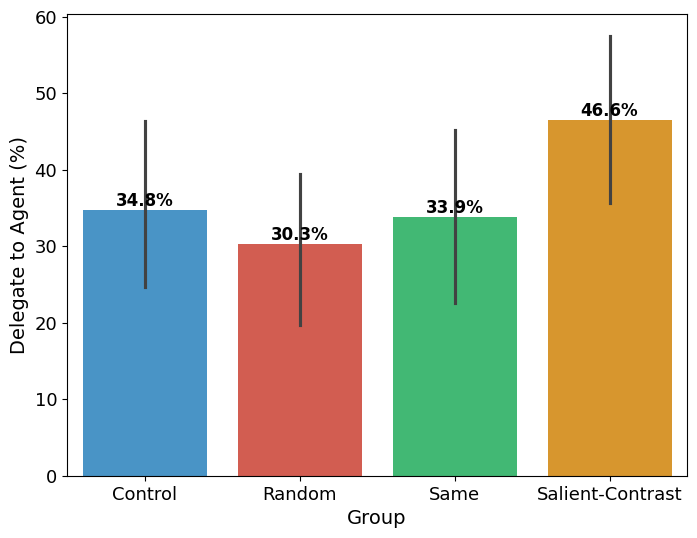

Mann-Whitney U Test Results for Delegate to by Group
            level_1           level_2       U   p_value
0           Control            Random  2740.5  0.719420
1           Control  Salient-Contrast  2221.5  0.077596
2           Control              Same  2158.5  0.544623
3            Random  Salient-Contrast  2321.5  0.020729
4            Random              Same  2271.0  0.327048
5  Salient-Contrast              Same  2550.5  0.932430


In [ ]:
# Plot: Delegate to Agent by Group
plot_barplot(
        user_results,
        'group',
        'trust_the_agent',
        y_label='Delegate to Agent (%)',
        x_label='Group',
        x_val_names=group_names,
        estimator=lambda x: np.mean(x) * 100,
        palette=colors_palette,
        errorbar=('ci', 95),
        order=group_names,
        save_path='images/delegate_to_agent_by_group.pdf',
        )

print("Mann-Whitney U Test Results for Delegate to by Group")
mannwhitneyu_test(user_results, 'trust_the_agent', 'group', test_type='less')

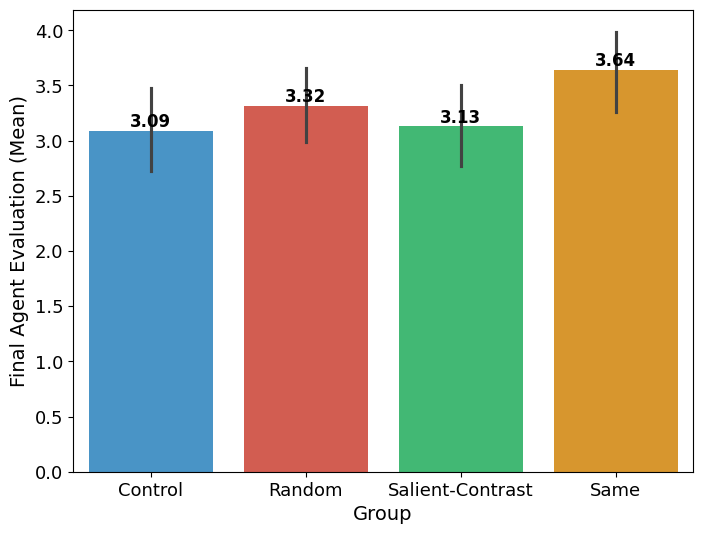

            level_1           level_2       U   p_value
0           Control            Random  2345.5  0.130683
1           Control  Salient-Contrast  1995.5  0.014471
2           Control              Same  2056.5  0.348729
3            Random  Salient-Contrast  2434.0  0.092773
4            Random              Same  2526.0  0.774061
5  Salient-Contrast              Same  2693.0  0.974463


In [13]:
# Plot: Final Agent Evaluation (Mean) by Group

plot_barplot(
        user_results,
        x_col='group',
        y_col='evaluate_final_agent',
        x_label='Group',
        y_label='Final Agent Evaluation (Mean)',
        estimator=lambda x: np.mean(x),
        palette=colors_palette,
        order=group_names,
        bar_label_fmt='%.2f',
)


mannwhitneyu_test(user_results, 'evaluate_final_agent', 'group', test_type='less')


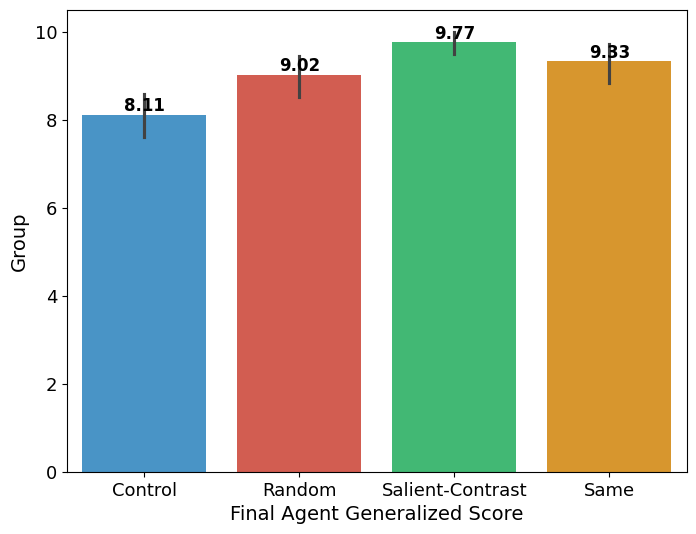

            level_1           level_2       U   p_value
0           Control            Random  1926.0  0.997597
1           Control  Salient-Contrast  1278.5  1.000000
2           Control              Same  1346.5  0.999914
3            Random  Salient-Contrast  2249.5  0.981710
4            Random              Same  2165.5  0.802461
5  Salient-Contrast              Same  2521.5  0.115271


In [14]:
# Plot: Final Agent Generalized Score by Group
plot_df = user_results
plot_barplot(plot_df,
                     'group',
                     'final_agent_mean_score',
                     x_label='Final Agent Generalized Score',
                     y_label='Group',
                     estimator='mean',
                     bar_label_fmt='%.2f',
                     palette=colors_palette,
)


mannwhitneyu_test(plot_df, 'final_agent_mean_score', 'group', test_type='greater')

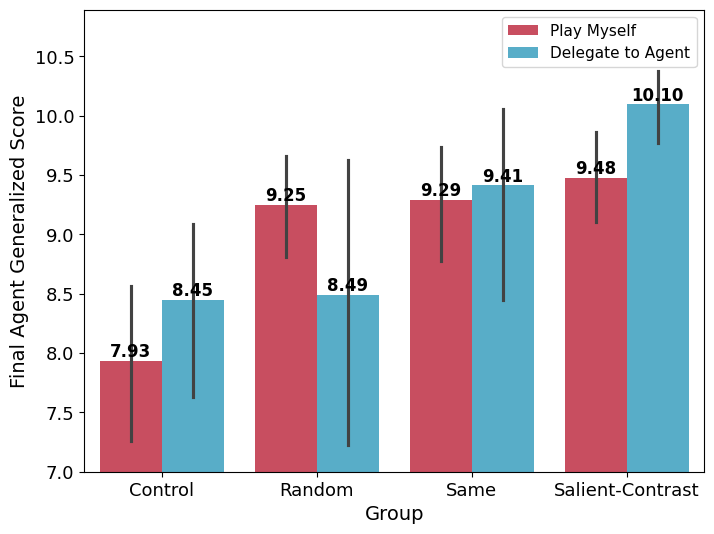

Mann-Whitney_u_test for group  Same
   level_1  level_2      U   p_value
0        0        1  403.5  0.340554
Mann-Whitney_u_test for group  Salient-Contrast
   level_1  level_2      U   p_value
0        0        1  449.0  0.006053
Mann-Whitney_u_test for group  Control
   level_1  level_2      U   p_value
0        0        1  461.0  0.152206
Mann-Whitney_u_test for group  Random
   level_1  level_2      U   p_value
0        0        1  640.0  0.642252


In [ ]:
# Plot: Final Agent Generalized Score by Group and Delegate separated
plot_df = user_results
plot_barplot(plot_df,
                     x_col='group',
                     y_col='final_agent_mean_score',
                     x_label='Group',
                     y_label='Final Agent Generalized Score',
                     hue='trust_the_agent',
                     hue_names=['Play Myself','Delegate to Agent'],
                     order=group_names,
                     x_val_names=group_names,
                     bar_label_fmt='%.2f',
                     estimator='mean',
                     palette=["#DC3A52", "#45B6DB"],  # light red and light blue
                     ylim_bottom=7,
                     save_path='images/final_agent_generalized_score_by_group_and_delegate_seperated.pdf'
)


for group in plot_df['group'].unique():
    print('Mann-Whitney_u_test for group ', group)
    mannwhitneyu_test(plot_df[plot_df['group'] == group], 'final_agent_mean_score', 'trust_the_agent', test_type='less')

## Satisfection from the System

ES_combined


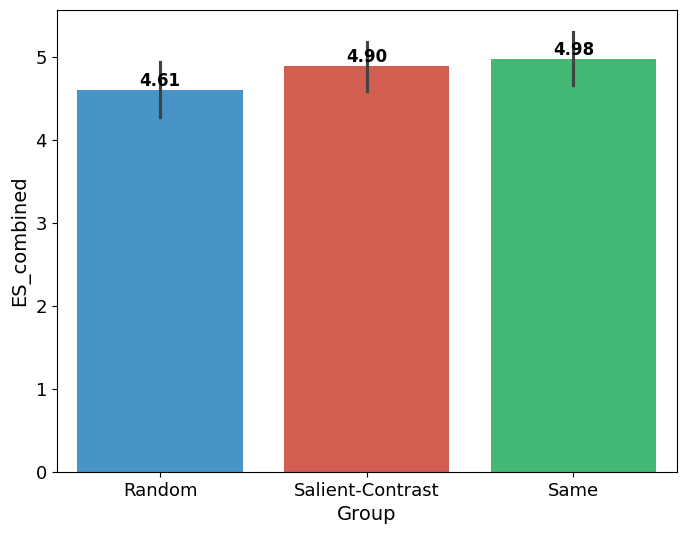

            level_1           level_2       U   p_value
0            Random  Salient-Contrast  2605.5  0.522581
1            Random              Same  2062.0  0.207937
2  Salient-Contrast              Same  2080.0  0.419203


In [16]:
# Plot: Experiment - Satisfection: Satisfection from the System (ES_combined Mean by Group)
ES_questions = ['ES_understandable', # understandable
                'ES_overwhelming', # ovelwhalming
                'ES_feedback_contribution',
                'ES_helpful',
                'ES_combined'
]


i = 4
print(ES_questions[i])

plot_df = user_results[user_results['group'] != 'Control']
plot_barplot(
    df=plot_df,
    y_col=ES_questions[i],
    x_col='group',
    palette=colors_palette,
    x_label='Group',
    y_label=ES_questions[i],
    estimator='mean',
    bar_label_fmt='%.2f',
    order=sorted(list(plot_df['group'].unique()))
)

mannwhitneyu_test(plot_df, ES_questions[i], 'group')